In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
df = pd.read_csv("online_retail_II.csv")
df.head()

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("online_retail_II.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'online_retail_II.csv'

In [5]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [6]:
df = pd.read_csv("online_retail_II.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'online_retail_II.csv'

In [7]:
import os
os.listdir()

['.config', 'archive.zip', 'sample_data']

In [8]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [9]:
import os
os.listdir("dataset")

['online_retail_II.csv']

In [10]:
import pandas as pd

df = pd.read_excel("dataset/online_retail_II.xlsx")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/online_retail_II.xlsx'

In [11]:
df = pd.read_csv("dataset/online_retail.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/online_retail.csv'

In [12]:
import pandas as pd

df = pd.read_csv("dataset/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df.shape

(1067371, 8)

In [14]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [16]:
df = df.dropna(subset=['Customer ID'])

In [17]:
df['Customer ID'] = df['Customer ID'].astype(int)

In [18]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [19]:
df = df[df['Quantity'] > 0]

In [20]:
df['order_value'] = df['Quantity'] * df['Price']

In [21]:
signup = df.groupby('Customer ID')['InvoiceDate'].min().reset_index()
signup.columns = ['CustomerID', 'signup_date']

df = df.merge(signup, left_on='Customer ID', right_on='CustomerID')

In [22]:
df['order_month'] = df['InvoiceDate'].dt.to_period('M')
df['signup_month'] = df['signup_date'].dt.to_period('M')

In [23]:
from operator import attrgetter

df['cohort_index'] = (
    df['order_month'] - df['signup_month']
).apply(attrgetter('n'))

In [24]:
cohort_data = df.groupby(
    ['signup_month', 'cohort_index']
)['CustomerID'].nunique()

cohort_table = cohort_data.reset_index().pivot(
    index='signup_month',
    columns='cohort_index',
    values='CustomerID'
)

In [25]:
cohort_size = cohort_table.iloc[:,0]

retention = cohort_table.divide(cohort_size, axis=0)

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt

SyntaxError: incomplete input (3581296732.py, line 6)

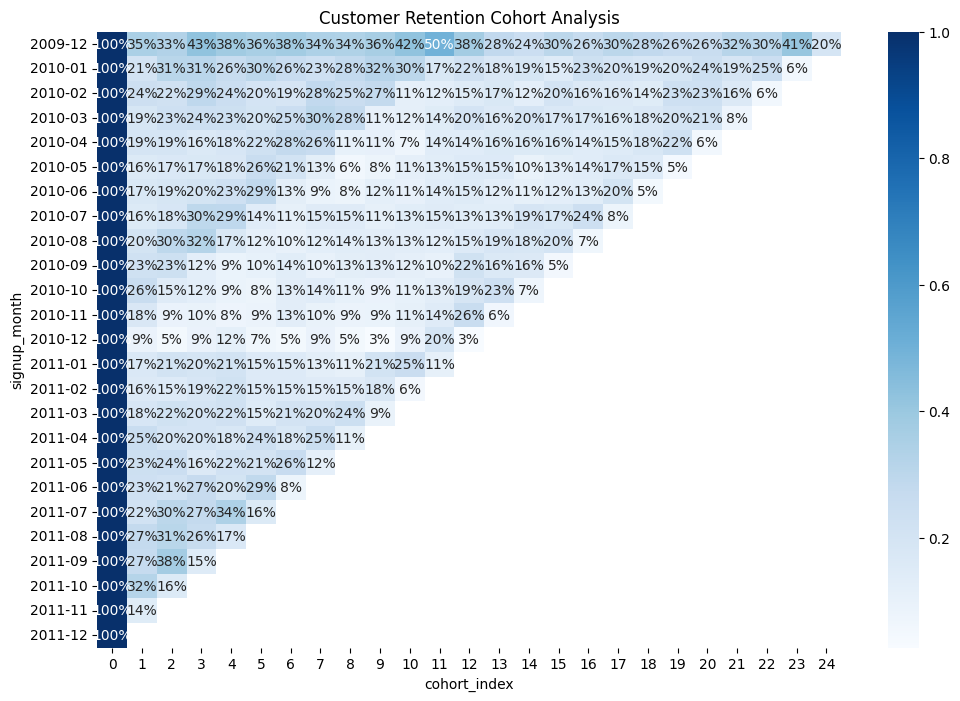

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")
plt.show()

In [29]:
plt.savefig("retention_heatmap.png")

<Figure size 640x480 with 0 Axes>

FileNotFoundError: [Errno 2] No such file or directory: 'visuals/retention_heatmap.png'

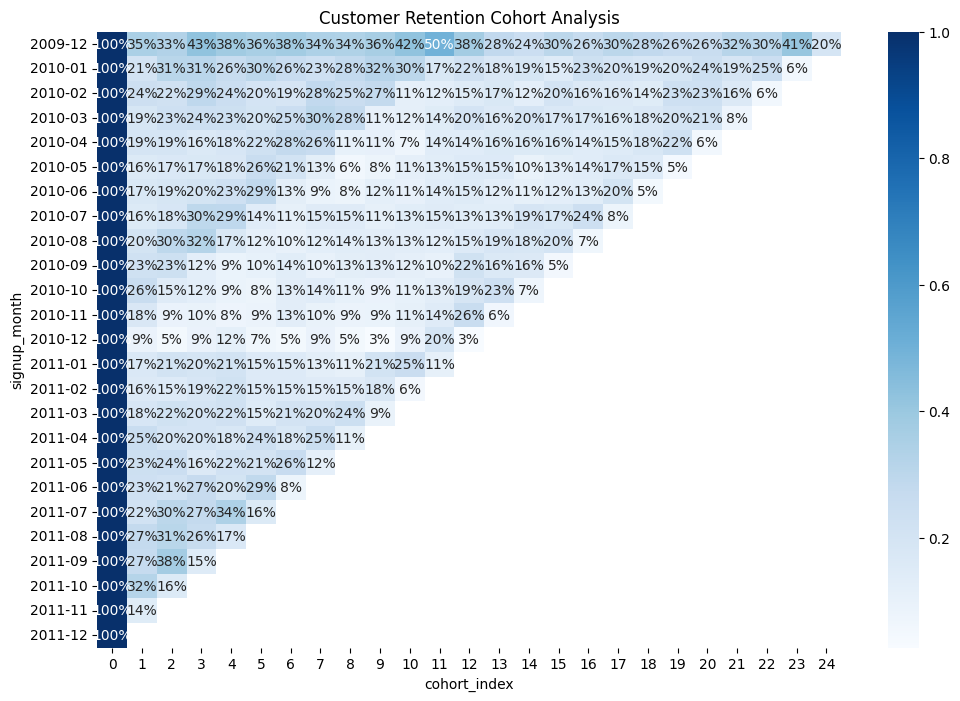

In [30]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")

plt.savefig("visuals/retention_heatmap.png")

plt.show()

In [31]:
from google.colab import files
files.download("retention_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from google.colab import files
files.download("retention_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

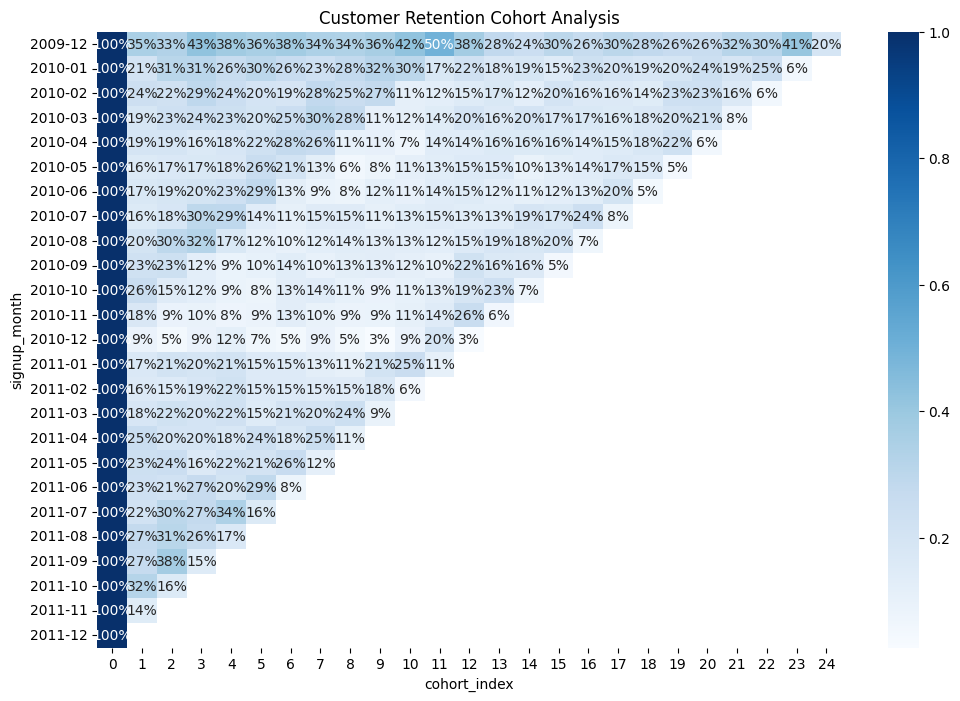

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")

# SAVE FIRST
plt.savefig("retention_heatmap.png", dpi=300, bbox_inches="tight")

# THEN SHOW
plt.show()

In [34]:
from google.colab import files
files.download("retention_heatmap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>